In [1]:
"""
Pedro Mauri Mtz - A01029143
Maximum Likelihood Estimation
"""

'\nPedro Mauri Mtz - A01029143\nMaximum Likelihood Estimation\n'

In [2]:
from sklearn.datasets import make_blobs
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.stats import entropy

In [3]:
X1, Y1 = make_blobs(n_features = 2, centers = 3, random_state = 43, cluster_std = 0.5)
Y1 = Y1.reshape(-1,1)
# print("X1", X1[::10])
# print("Y1", Y1[::10])
X = np.hstack((X1,Y1))
X[::10]

array([[-3.5822916 ,  6.92833462,  2.        ],
       [-2.44946968,  6.66702575,  2.        ],
       [-7.55065779, -4.67863944,  1.        ],
       [-7.67716662, -5.28738495,  1.        ],
       [-7.24156325, -5.6007935 ,  1.        ],
       [-2.95076764,  7.20427269,  2.        ],
       [-8.03841223,  2.94582335,  0.        ],
       [-3.35457229,  6.57092995,  2.        ],
       [-7.23034302, -6.11646795,  1.        ],
       [-8.53324003,  1.75028804,  0.        ]])

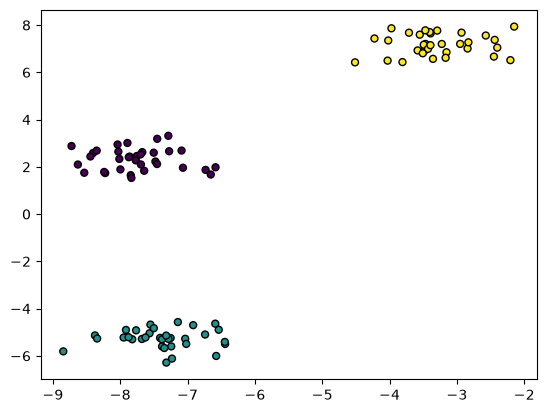

In [4]:
plt.scatter(X1[:, 0], X1[:, 1], marker = "o", c = Y1, s = 25, edgecolor = "k")
plt.show()

##Actividad en clase:

Pedro Mauri Mtz - A01029143

Graficar valores de "mu" y "sigma" para cada característica de cada cluster, con el objetido de ver su comportamiento.

In [5]:
# Separar clusters

def split_clusters(cluster):

  x_c = cluster[:, 0]
  y_c = cluster[:, 1]

  return x_c, y_c

In [6]:
def get_mu_sigma(array):

  mu, sigma = [], []
  mu_t, sigma_t = 0, 0

  for t in range(len(array)):
    N = t + 1

    mu_t += 1/N * (array[t] - mu_t)
    mu.append(mu_t)

    sigma_t += 1/N * ((array[t] - mu_t) ** 2 - sigma_t)
    sigma.append(sigma_t)

  return mu, sigma

In [7]:
def err_curve(array, mu_array, sigma_array):
  err_curve = []

  pi = math.pi

  for t in range(len(sigma_array)):
    N = t + 1

    mu_t = mu_array[t]
    sigma_t = sigma_array[t]

    # Evitar valores negativos o cero
    if sigma_t <= 0:
        err_curve.append(0)
        continue

    sum_data_mu = 0
    for i in range(N):
      sum_data_mu += (array[i] - mu_array[i]) ** 2

    err_curve_t = - (N/2) * (math.log(2 * pi)) - (N/2) * (math.log(sigma_array[t])) - (1 / (2 * sigma_array[t])) * sum_data_mu
    err_curve.append(err_curve_t)

  return err_curve

In [8]:
def get_pdf(array, mu, sigma):

    pi = math.pi

    x_values = np.linspace(min(array), max(array), len(array))

    pdf_values = (1 / (np.sqrt(2 * np.pi) * np.sqrt(sigma))) * np.exp(-((x_values - mu) ** 2) / (2 * sigma))

    return x_values, pdf_values

In [9]:
def plot_pdf(array, mu, sigma, cluster):

    x, pdf = get_pdf(array, mu, sigma)

    # Histograma normalizado (densidad)
    plt.hist(array, bins = 15, density = True, alpha = 0.6, color = 'skyblue', edgecolor = 'black', label = 'Data')

    # PDF teórica
    plt.plot(x, pdf, color = 'red', linewidth = 2, label = f'PDF μ={mu:.2f}, σ²={sigma:.2f}')

    # plt.legend()
    plt.xlabel('Data')
    plt.ylabel("Probability's Density")
    plt.title(f'PDF for {cluster}')
    plt.grid(True)

    plt.show()

In [10]:
def plot_mu(mu_array_x, mu_array_y, cluster):

  plt.plot(mu_array_x)
  plt.plot(mu_array_y)

  plt.legend(["mu for X", "mu for y"])
  plt.title(f"Mu Values for {cluster}")
  plt.grid(True)

  plt.show()

In [11]:
def plot_sigma(sigma_array_x, sigma_array_y, cluster):

  plt.plot(sigma_array_x)
  plt.plot(sigma_array_y)

  plt.legend(["Sigma for X", "Sigma for y"])
  plt.title(f"Plotting Sigma for {cluster}")
  plt.grid(True)

  plt.show()

In [12]:
def plot_err_curve(err_curve_x, err_curve_y, cluster):

  plt.plot(err_curve_x)
  plt.plot(err_curve_y)

  plt.legend(["Error Curve for X", "Error Curve for y"])
  plt.title(f"Error Curve for {cluster}")
  plt.grid(True)

  plt.show()

In [13]:
# Splitting clusters:

cluster_0 = X[X[:,2] == 0]
cluster_1 = X[X[:,2] == 1]
cluster_2 = X[X[:,2] == 2]

x_c0, y_c0 = split_clusters(cluster_0)
x_c1, y_c1 = split_clusters(cluster_1)
x_c2, y_c2 = split_clusters(cluster_2)

# CLUSTER 0
# x
mu_x_c0, sigma_x_c0 = get_mu_sigma(x_c0)
err_curve_x_c0 = err_curve(x_c0, mu_x_c0, sigma_x_c0)
# y
mu_y_c0, sigma_y_c0 = get_mu_sigma(y_c0)
err_curve_y_c0 = err_curve(y_c0, mu_y_c0, sigma_y_c0)

# CLUSTER 1
# x
mu_x_c1, sigma_x_c1 = get_mu_sigma(x_c1)
err_curve_x_c1 = err_curve(x_c1, mu_x_c1, sigma_x_c1)
# y
mu_y_c1, sigma_y_c1 = get_mu_sigma(y_c1)
err_curve_y_c1 = err_curve(y_c1, mu_y_c1, sigma_y_c1)

# CLUSTER 2
# x
mu_x_c2, sigma_x_c2 = get_mu_sigma(x_c2)
err_curve_x_c2 = err_curve(x_c2, mu_x_c2, sigma_x_c2)
# y
mu_y_c2, sigma_y_c2 = get_mu_sigma(y_c2)
err_curve_y_c2 = err_curve(y_c2, mu_y_c2, sigma_y_c2)

Mu (media) de Cluster 0: x: -7.755850286607258, y: 2.321010771877286


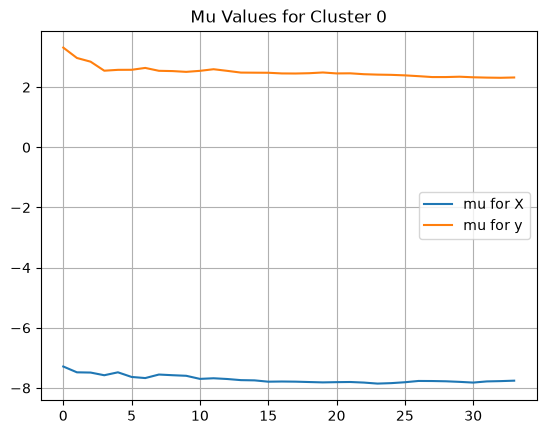

Sigma (varianza) de Cluster 0: x: 0.2644767695952346, y: 0.18919016612854223


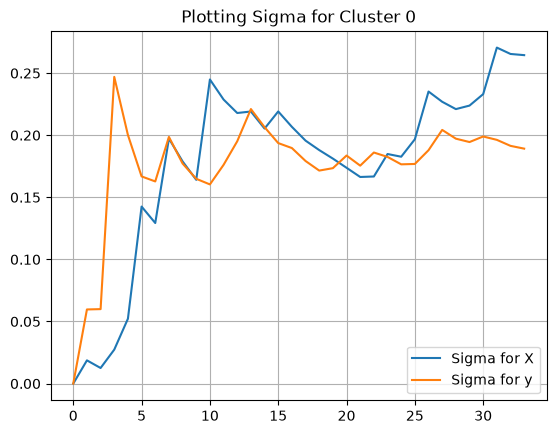

Curva de error de Cluster 0: x: -25.633878523270912, y: -19.938865932699745


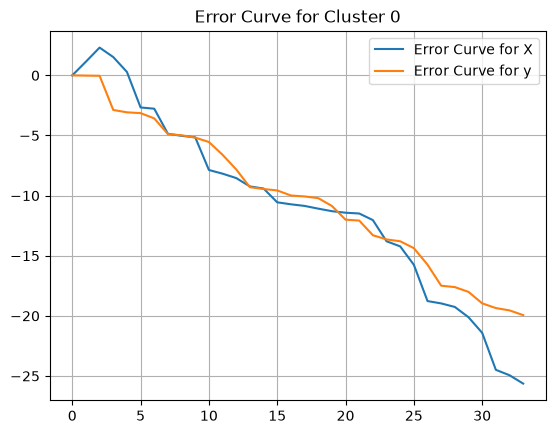

PDF de Cluster 0 x:


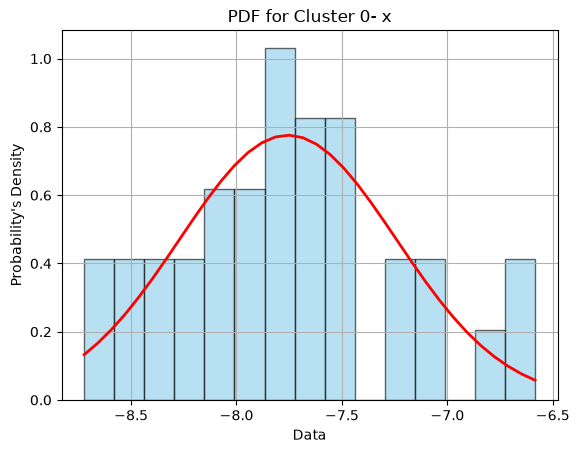

PDF de Cluster 0 y:


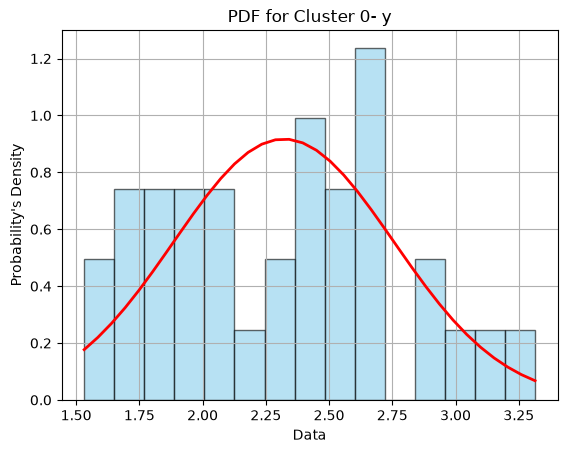

In [14]:
cluster = "Cluster 0"

print(f"Mu (media) de {cluster}: x: {mu_x_c0[-1]}, y: {mu_y_c0[-1]}")
plot_mu(mu_x_c0, mu_y_c0, cluster)

print(f"Sigma (varianza) de {cluster}: x: {sigma_x_c0[-1]}, y: {sigma_y_c0[-1]}")
plot_sigma(sigma_x_c0, sigma_y_c0, cluster)

print(f"Curva de error de {cluster}: x: {err_curve_x_c0[-1]}, y: {err_curve_y_c0[-1]}")
plot_err_curve(err_curve_x_c0, err_curve_y_c0, cluster)

print(f"PDF de {cluster} x:")
plot_pdf(x_c0, mu_x_c0[-1], sigma_x_c0[-1], cluster + "- x")

print(f"PDF de {cluster} y:")
plot_pdf(y_c0, mu_y_c0[-1], sigma_y_c0[-1], cluster + "- y")


Mu (media) de Cluster 1: x: -7.375141984114882, y: -5.2700933448410625


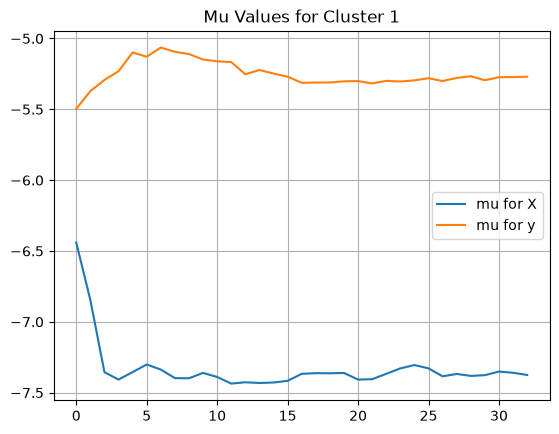

Sigma (varianza) de Cluster 1: x: 0.27682100030624596, y: 0.1504816292045623


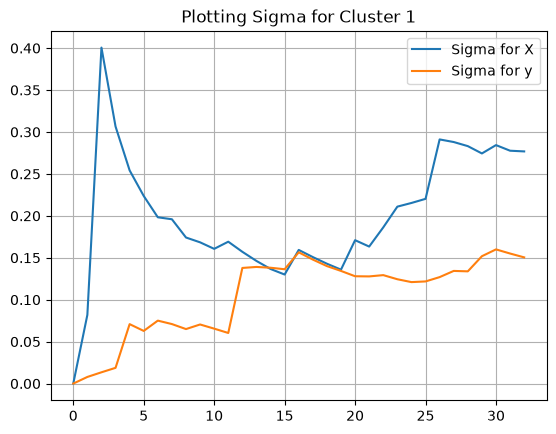

Curva de error de Cluster 1: x: -25.632632461446164, y: -15.575386184813805


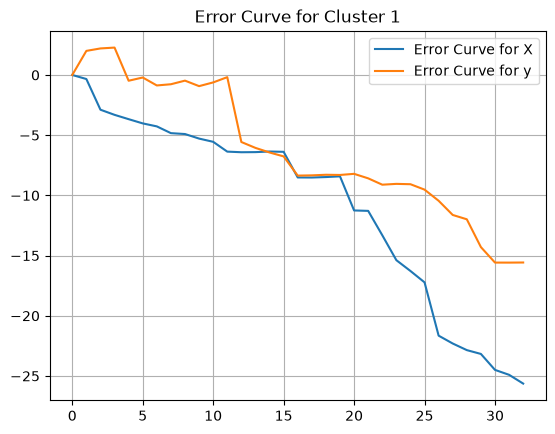

PDF de Cluster 1 x:


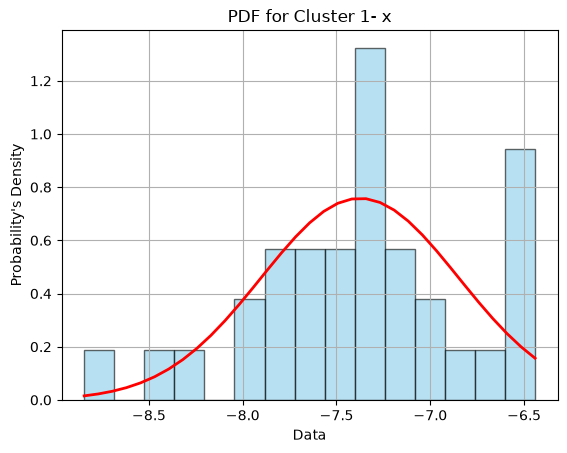

PDF de Cluster 1 y:


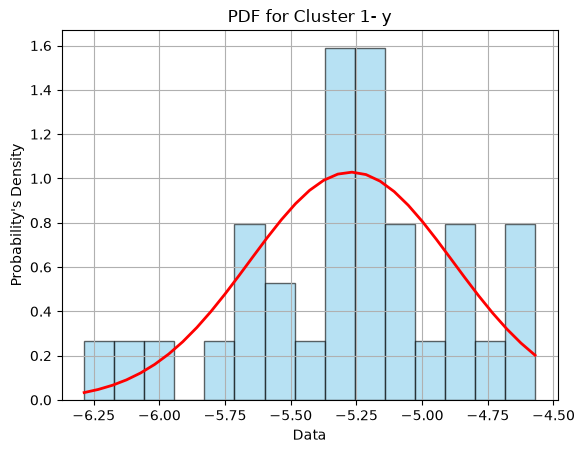

In [15]:
cluster = "Cluster 1"

print(f"Mu (media) de {cluster}: x: {mu_x_c1[-1]}, y: {mu_y_c1[-1]}")
plot_mu(mu_x_c1, mu_y_c1, cluster)

print(f"Sigma (varianza) de {cluster}: x: {sigma_x_c1[-1]}, y: {sigma_y_c1[-1]}")
plot_sigma(sigma_x_c1, sigma_y_c1, cluster)

print(f"Curva de error de {cluster}: x: {err_curve_x_c1[-1]}, y: {err_curve_y_c1[-1]}")
plot_err_curve(err_curve_x_c1, err_curve_y_c1, cluster)

print(f"PDF de {cluster} x:")
plot_pdf(x_c1, mu_x_c1[-1], sigma_x_c1[-1], cluster + "- x")

print(f"PDF de {cluster} y:")
plot_pdf(y_c1, mu_y_c1[-1], sigma_y_c1[-1], cluster + "- y")

Mu (media) de Cluster 2: x: -3.2842996861753244, y: 7.176902248957355


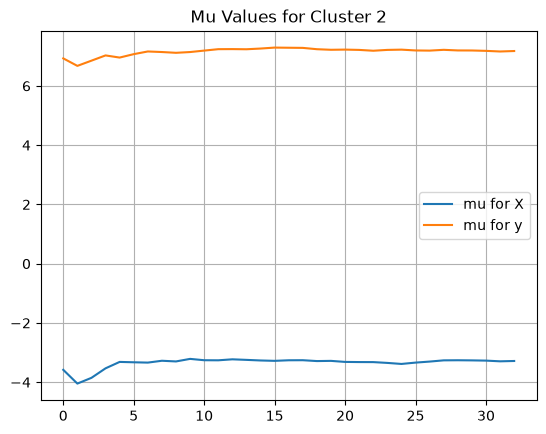

Sigma (varianza) de Cluster 2: x: 0.28751260740450085, y: 0.18324023900317962


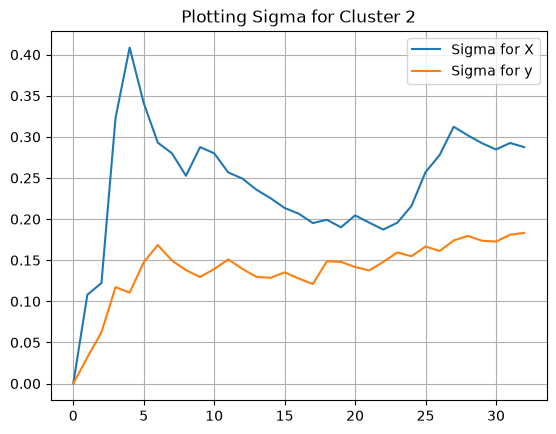

Curva de error de Cluster 2: x: -26.25791022599071, y: -18.825177702583265


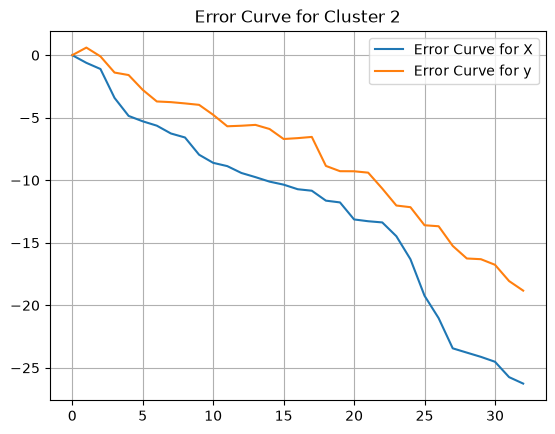

PDF de Cluster 2 x:


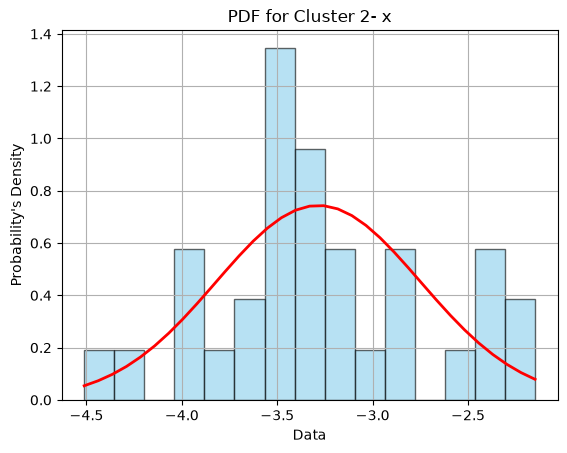

PDF de Cluster 2 y:


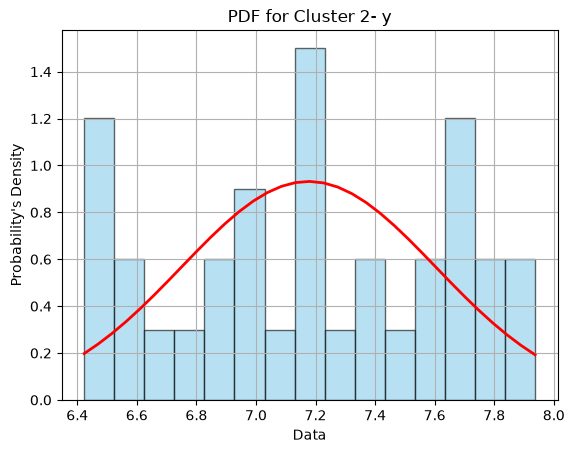

In [16]:
cluster = "Cluster 2"

print(f"Mu (media) de {cluster}: x: {mu_x_c2[-1]}, y: {mu_y_c2[-1]}")
plot_mu(mu_x_c2, mu_y_c2, cluster)

print(f"Sigma (varianza) de {cluster}: x: {sigma_x_c2[-1]}, y: {sigma_y_c2[-1]}")
plot_sigma(sigma_x_c2, sigma_y_c2, cluster)

print(f"Curva de error de {cluster}: x: {err_curve_x_c2[-1]}, y: {err_curve_y_c2[-1]}")
plot_err_curve(err_curve_x_c2, err_curve_y_c2, cluster)

print(f"PDF de {cluster} x:")
plot_pdf(x_c2, mu_x_c2[-1], sigma_x_c2[-1], cluster + "- x")

print(f"PDF de {cluster} y:")
plot_pdf(y_c2, mu_y_c2[-1], sigma_y_c2[-1], cluster + "- y")